In [66]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import quad

from tracklab import ExperimentReader
from configurations import create_fig, set_font_sizes, apply_general_styles, save_fig

apply_general_styles()
set_font_sizes('tight')

# Timescales

In [154]:
def g(x,lmbda):
    return 1 - np.exp(-lmbda*x)

def integrand_ode(x, lmbda, A, V, omega):
    num = 2*V*x
    denom =  (V-1) +  np.exp(A*omega*x/g(x,lmbda))
    return num/denom


def psi_function(omega,lmbda,A,V):
    return quad(integrand_ode, 0, 1, args=(lmbda, A, V, omega))[0]

def c_lambda(lmbda):
    return quad(lambda x: x**2/g(x,lmbda), 0, 1)[0]

def p_lambda(lmbda):
    return quad(lambda x: x**3/(g(x,lmbda))**2, 0, 1)[0]

def psi_approx1(omega,cte_lambda,A,V):
    return 1 - 2*A*cte_lambda*omega/V

def psi_approx2(omega,cte_lambda,p_lambda,A,V):
    return 1 - 2*A*cte_lambda*omega/V - A**2*p_lambda*omega**2/V


def gradient(q, t, lmbda, A, V, K, L, B):
    M = q[0]
    Q = q[1]
    G = q[2]
    omega = M*Q*G/K
    psi = psi_function(omega,lmbda,A,V)
    common_term = B * psi / K

    # tau = V**2*np.sqrt(L)

    dM = common_term * Q * G / L
    dQ = common_term * M * G / K
    dG = common_term * M * Q / (V-K)


    return np.array([dM, dQ, dG]) #*tau

def extract_parameters(value,name_variable):
    if name_variable == 'd_model':
        d = value
        V = V_fixed
        L = L_fixed
    elif name_variable == 'vocab_size':
        d = d_fixed
        V = value
        L = L_fixed
    elif name_variable == 'seq_len':
        d = d_fixed
        V = V_fixed
        L = value
    else:
        raise ValueError(f"Unknown variable name: {name_variable}")
    return d, V, L

def formated_values(name_variable):
    lb_err = None
    lb_ode = None
    if name_variable == 'd_model':
        title = rf"$(V,L)=({V_fixed},{L_fixed})$"
        xlabel = r"$d$"
        lb_ode = f'Ode'
        lb_err = f'Sim.'
    elif name_variable == 'vocab_size':
        title = rf"$(d,L)=({d_fixed},{L_fixed})$"
        xlabel = r"$V$"
        
    elif name_variable == 'seq_len':
        title = rf"$(d,V)=({d_fixed},{V_fixed})$"
        xlabel = r"$L$"
    else:
        raise ValueError(f"Unknown variable name: {name_variable}")
    return title, xlabel, lb_err, lb_ode

In [155]:
experiment_name = 'swap_experiments'
reader = ExperimentReader(experiment_name,base_dir='../data')
summary = reader.summarize_runs()
summary['T'] = None

for i in range(len(summary)):
    row = summary.iloc[i]
    run_id = row['run_id']
    metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()
    idx_transition = np.where(metrics['top1_accuracy']>0.5)[0]
    if len(idx_transition) > 0:
        T_transition = metrics['step'][idx_transition[0]]
        summary.loc[i,'T'] = T_transition

# Filter out runs that did not reach the transition on a copy dataframe to avoid SettingWithCopyWarning
filtered_summary = summary[summary['T'].notnull()].copy()

# Filter out specific runs 
runs_out = ['run_107',]

# filtered_summary[
#     (filtered_summary['vocab_size'] == 128) &
#     (filtered_summary['seq_len'] == 128)&
#     (filtered_summary['d_model'] == 256)
# ]

filtered_summary = filtered_summary[~filtered_summary['run_id'].isin(runs_out)]

print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].tail())

# Replace nans with 0 in the filtered_summary dataframe
filtered_summary.fillna(0, inplace=True)

# Group all runs with same vocab_size & seq_len and compute mean and std of T
grouped = filtered_summary.groupby(['vocab_size','seq_len','d_model'])['T'].agg(['mean','std']).reset_index()
print(grouped)

      run_id  vocab_size  d_model  seq_len      T
112  run_113         128      512      128   4082
114  run_115         128       64      128  10645
115  run_116         128      128      128   3201
116  run_117         128      256      128   1760
117  run_118         128      512      128   2721
    vocab_size  seq_len  d_model         mean           std
0           32      128      256        232.0     79.554314
1           64      128      256       1200.7    768.259801
2          128       32      256      16431.7   5548.804437
3          128       64      256       7294.7   4889.672678
4          128      128       64       5586.6   3166.522746
5          128      128      128       4705.8   3272.808534
6          128      128      256  4305.928571   3109.812373
7          128      128      512       5794.4   3393.059136
8          128      256      256       4932.2   2881.660817
9          128      512      256       3691.0   2599.474562
10         256      128      256      31

In [156]:
# Fixed Parameters
d_fixed = 256
V_fixed = 128
L_fixed = 128

rho = 0.2
beta = 0.25
bs = 512
eta_0 = 3 * bs

A = beta * (rho / (1+rho))
B = 0.5*beta*eta_0*(rho/(1+rho))**2

cnst = (1/B) * rho * np.sqrt(rho*(1-rho))

In [157]:
parameters = {
    'vocab_size': V_fixed,
    'seq_len': L_fixed,
    'd_model': d_fixed
}
names = parameters.keys()

transition_time_ode = {name_variable: [] for name_variable in names}
for name_variable in names:
    # Filter dataframe with the other two fixed parameters
    rest_names = [n for n in names if n != name_variable]
    data = grouped[(grouped[rest_names[0]] == parameters[rest_names[0]]) & (grouped[rest_names[1]] == parameters[rest_names[1]])]
    values_variable = data[name_variable].values
   
    for value in values_variable:
        d, V, L = extract_parameters(value, name_variable)
        lmbda = L/((1+rho)*V)
        K = int(rho*V)
        # Initial values
        M0 , Q0 , G0 = 1/np.sqrt(L), np.sqrt((K+d+1)/(K*d)), 1/np.sqrt(V-K)
        q0 = np.array([M0, Q0, G0])

        # Integrate ODE
        ode_times = np.linspace(0, 60000, 1000)
        solution = odeint(gradient, q0, ode_times, args=(lmbda, A, V, K, L, B))
        Mth, Qth, Gth = solution[:,0], solution[:,1], solution[:,2]
        Omega_th = Mth*Qth*Gth/K
        idx_transition = np.where(Omega_th > 1)[0]
        if len(idx_transition) > 0:
            T_transition = ode_times[idx_transition[0]]
            transition_time_ode[name_variable].append(T_transition)
            # print(f'For {name_variable}={value}, the transition time T is approximately: {T_transition}')
        else:
            transition_time_ode[name_variable].append(np.nan)
            print(f'For {name_variable}={value}, the transition time T was not reached within the integration time.')


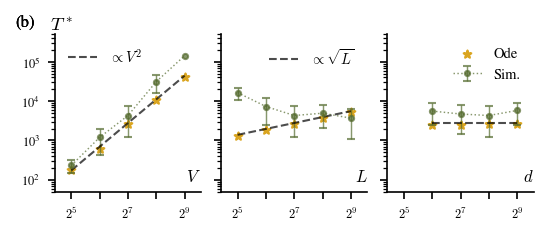

In [12]:
fig , axes = create_fig(ncols=len(names),h=0.4,sharey=True)
for i, name_variable in enumerate(names):
    ax = axes[i]
    title, xlabel , lb_err, lb_ode = formated_values(name_variable)
    if i==0: ax.set_ylabel(r'$T^*$',fontsize=9,loc='top',rotation=0,labelpad=-25)
    # ax.set_title(title, fontsize=8)
    ax.set_xlabel(xlabel,fontsize=8,labelpad=-25,loc='right')

    # Filter dataframe with the other two fixed parameters
    rest_names = [n for n in names if n != name_variable]
    data = grouped[(grouped[rest_names[0]] == parameters[rest_names[0]]) & (grouped[rest_names[1]] == parameters[rest_names[1]])]
    x = data[name_variable].values
    avT = data['mean'].values
    stdT = data['std'].values
    odeT = np.array(transition_time_ode[name_variable])

    ax.errorbar(x, avT, yerr=stdT, marker='o', label=lb_err, color='darkolivegreen', markersize=2.5, capsize=2,elinewidth=0.7,ls=':',lw=0.7,alpha=0.7)
    ax.scatter(x, odeT, label=lb_ode, color='goldenrod', marker='*', s=15)
        
    
    if name_variable == 'vocab_size':
        T_predict = cnst * (x**2) * np.sqrt(L_fixed)
        ax.plot(x, T_predict, label=r'$\propto V^2$', color='k',linestyle='--', linewidth=1,alpha=0.7)
    if name_variable == 'seq_len':
        T_predict = cnst * (V_fixed**2) * np.sqrt(x)
        ax.plot(x, T_predict, label=r'$\propto \sqrt{L}$',  color='k',linestyle='--', linewidth=1,alpha=0.7)
    if name_variable == 'd_model':
        T_predict = cnst * (V_fixed**2) * np.sqrt(L_fixed)
        ax.plot(x, T_predict*np.ones_like(x),  color='k',linestyle='--', linewidth=1,alpha=0.7)


    ax.legend(fontsize=7,frameon=False)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')    
    ax.set_xlim([2**5/1.5,1.5*2**9])
    ax.set_ylim(bottom=50,top=5*10**5)
    ax.set_xticks([2**5, 2**6, 2**7, 2**8, 2**9],[r'$2^5$', None , r'$2^7$', None, r'$2^9$'])
    # if i>0 : ax.set_yticklabels([])

    fig.text(0.0,0.96,'(b)',fontsize=8)

# save_fig(fig,'time_scales',base_dir='../../Manuscript/figures')


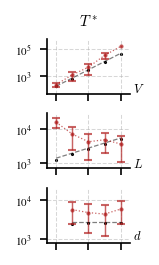

In [213]:
fig , axes = create_fig(ncols=1,nrows=3,h=0.23,size='double',w=1.3/11)


# fig , axes = create_fig(ncols=len(names),h=0.4,sharey=True)
for i, name_variable in enumerate(names):
    ax = axes[i]
    ax.grid(lw=0.5,ls='--',alpha=0.5)
    title, xlabel , lb_err, lb_ode = formated_values(name_variable)
    # if i==0: ax.set_ylabel(r'$T^*$',fontsize=9,loc='top',rotation=0,labelpad=-25)
    if i==0: ax.set_title(r'$T^*$')
    # ax.set_title(title, fontsize=8)
    # ax.set_xlabel(xlabel,fontsize=8,labelpad=-25,loc='right')

    # Filter dataframe with the other two fixed parameters
    rest_names = [n for n in names if n != name_variable]
    data = grouped[(grouped[rest_names[0]] == parameters[rest_names[0]]) & (grouped[rest_names[1]] == parameters[rest_names[1]])]
    x = data[name_variable].values
    avT = data['mean'].values
    stdT = data['std'].values
    odeT = np.array(transition_time_ode[name_variable])

    ax.errorbar(x, avT, yerr=stdT, marker='o', label=lb_err, color='firebrick', markersize=1.0, capsize=2,elinewidth=0.7,ls=':',lw=0.6,alpha=0.7)
    ax.scatter(x, odeT, label=lb_ode, color='k', marker='.', s=1)
        
    
    if name_variable == 'vocab_size':
        T_predict = cnst * (x**2) * np.sqrt(L_fixed)
        ax.plot(x, T_predict, label=r'$\propto V^2$', color='k',linestyle='--', linewidth=0.6,alpha=0.5)
    if name_variable == 'seq_len':
        T_predict = cnst * (V_fixed**2) * np.sqrt(x)
        ax.plot(x, T_predict, label=r'$\propto \sqrt{L}$',  color='k',linestyle='--', linewidth=0.6,alpha=0.5)
    if name_variable == 'd_model':
        T_predict = cnst * (V_fixed**2) * np.sqrt(L_fixed)
        ax.plot(x, T_predict*np.ones_like(x),  color='k',linestyle='--', linewidth=0.6,alpha=0.5)


    # ax.legend(fontsize=7,frameon=False)
    ax.set_xscale('log', base=2)
        
    ax.set_xlim([(2**5/1.5,1.5*2**9),(2**5/1.5,1.5*2**9),(2**5/1.5,1.5*2**9)][i])
    ax.set_ylim([(50,5*10**5),(700,0.3*10**5),(800,2*10**4)][i])
    # remove minor ticks
    ax.tick_params(axis='both', which='minor', bottom=False, left=False)
    # ax.set_ylim(bottom=50,top=5*10**5)
    # ax.set_yticks()
    ax.set_xticks([2**5, 2**7, 2**9],[None, None, None])
    ax.set_yscale('log')
    # if i>0 : ax.set_yticklabels([])
xloc = 0.97
for loc , txt in zip([(xloc,0.07),(xloc,0.36),(xloc,0.66)],[r'$d$',r'$L$',r'$V$']):
    fig.text(loc[0],loc[1],txt,fontsize=6,transform=fig.transFigure)

    # fig.text(0.0,0.96,'(b)',fontsize=8)

# save_fig(fig,'time_scales',base_dir='../../Manuscript/figures')
fig.savefig(path/'time_scales.svg', format='svg', bbox_inches='tight', dpi=300)

# FULL PLOT


## Helper functions

In [125]:
# Helper functions
def f(x,m):
    return 1 - np.exp(-m*x)

def integrand(x,*args):
    m = args[0]
    A = args[1]
    V = args[2]
    omega = args[3]
    
    return f(x,m)*np.log( 1 + (V-1) * np.exp(-A*omega*x/f(x,m)) )

def _get_on_masks(V,L,K):
    _mask_M_on = np.zeros((L,L))
    _mask_Q_on = np.zeros((V,V))
    _mask_G_on = np.zeros((V,V))
    for i in range(1,L):
        _mask_M_on[i,i-1] = 1
    for i in range(V):
        if i < K:
            _mask_Q_on[i,i] = 1
        else:
            _mask_G_on[i,i] = 1
    return {
        'M': _mask_M_on.astype(bool),
        'Q': _mask_Q_on.astype(bool),
        'G': _mask_G_on.astype(bool)
    }

def _evaluate_matrices(masks, matrices):
    results = {}
    for kw in ['M','Q','G']:
        mask = masks[kw]
        mtx = matrices[kw]
        results[kw] = mtx[mask].mean()
    return results

def get_args(cfg):
    L , V, d, rho, K , beta , bs  = (cfg['model_args']['seq_len'], 
                                        cfg['model_args']['vocab_size'],
                                        cfg['model_args']['d_model'],
                                        cfg['data_args']['rho'],
                                        cfg['data_args']['K'],
                                        cfg['model_args']['beta'],
                                        cfg['data_args']['batch_size'],
                                        )
    
    eta_0 = cfg['optim_args']['lr']*d
    lmbd = L/((1+rho)*V)
    A = beta*rho/(1+rho)
    av_Pind = (rho/(1+rho))* (lmbd-1+np.exp(-lmbd))/lmbd
    limit_loss = (1-av_Pind)*np.log(V) + np.log(1-rho)*rho/(1+rho) * (1-np.exp(-lmbd))/lmbd
    B = 0.5*beta*eta_0*(rho/(1+rho))**2

    return L , V, d, rho, K , beta , bs , eta_0, lmbd, A, av_Pind, limit_loss , B

def add_order_parameters(reader,run_id):
    metrics = reader.load_metrics(run_id)
    metrics = metrics.pivot(index='step', columns='metric', values='value').reset_index()

    list_mtx = reader.list_artifacts(run_id,'matrices')
    list_mtx = list_mtx.pivot(index='step',columns='name',values='file').reset_index()
    n_prints = len(list_mtx)
    # Compute 'on' order parameters
    results = {'M': [], 'Q': [], 'G': [] }

    # Loop over the matrices and compute the order parameters
    masks = _get_on_masks(V,L,K)
    for i in range(n_prints):
        row = list_mtx.iloc[i]
        matrices = { kw: reader.load_artifact(run_id,row[kw],'matrices') for kw in ['M','Q','G']}
        res = _evaluate_matrices(masks, matrices)
        for kw in ['M','Q','G']:
            results[kw].append(res[kw])

    # Create a new dataframe with the results and concatenate it with the metrics dataframe
    results_df = pd.DataFrame(results)
    new_metrics = pd.concat([metrics,results_df],axis=1)
    new_metrics['M'] = new_metrics['M']/np.sqrt(d)
    new_metrics['Q'] = new_metrics['Q']/np.sqrt(d)
    new_metrics['G'] = new_metrics['G']/np.sqrt(d)
    new_metrics['omega'] = new_metrics['M']*new_metrics['Q']*new_metrics['G'] / K

    return new_metrics


def solve_ode(ode_times,lmbda, A, V, K, L, B, limit_loss, rho):
    # Initial values
    M0 , Q0 , G0 = 1/np.sqrt(L), np.sqrt((K+d+1)/(K*d)), 1/np.sqrt(V-K)
    q0 = np.array([M0, Q0, G0])
    # Integrate ODE
    solution = odeint(gradient, q0, ode_times, args=(lmbda, A, V, K, L, B))
    Mth, Qth, Gth = solution[:,0], solution[:,1], solution[:,2]
    Omega_th = Mth*Qth*Gth/K

   
    L_th = np.array([quad(integrand, 0, 1, args=(lmbda, A, V, om))[0] for om in Omega_th])
    L_th = L_th * rho/(1+rho) + limit_loss

    solution_df = pd.DataFrame({
        'step': ode_times,
        'M': Mth,
        'Q': Qth,
        'G': Gth,
        'omega': Omega_th,
        'loss': L_th})
    return solution_df



def get_artifacts_to_plot(reader,run_id,t_fracs,L,ell=2):
    list_mtx = reader.list_artifacts(run_id,'matrices')
    list_mtx = list_mtx.pivot(index='step',columns='name',values='file').reset_index()
    t_idx = [int(frac * len(list_mtx)) for frac in t_fracs]

    matrices = {'M': [], 'Q': [], 'G': []}
    for i in t_idx:
        row = list_mtx.iloc[i]
        for kw in ['M','Q','G']: matrices[kw].append(reader.load_artifact(run_id,row[kw],'matrices')/np.sqrt(d))


    # Load logits
    list_logits = reader.list_artifacts(run_id,'logits')

    on_logits = []
    off_logits = []
    all_logits = []
    for filename in list_logits['file'].values:
        lg = reader.load_artifact(run_id,filename,'logits')
        on_logits.append(lg['on'])
        off_logits.append(lg['off'])
        all_logits.append(lg['all'])


    complete_logits = {'on':[],'off':[],'all':[]}
    for idx in t_idx:
        complete_logits['on'].append( np.concatenate([on_logits[idx][L-l].flatten() for l in range(1,ell+1)]))
        complete_logits['off'].append( np.concatenate([off_logits[idx][L-l].flatten() for l in range(1,ell+1)]))
        complete_logits['all'].append(all_logits[idx][-1])

    max_indexes = complete_logits['all'][-1][:,:70].max(axis=1).argsort()[-20:]
    for i,_ in enumerate(t_idx):
        complete_logits['all'][i] = complete_logits['all'][i][max_indexes]


    artifacts = matrices | complete_logits

    _range = {}
    for kw in artifacts.keys():
        mtxs = artifacts[kw]
        max_val = max([np.abs(mtx).max() for mtx in mtxs])
        _range[kw] = max_val

    return artifacts, _range


## Plots

In [126]:
# Constants
time_fraction = 0.05
time_middle = 0.42
t_fracs = [time_middle-time_fraction, time_middle, time_middle+time_fraction]

# Instantiate the reader and pick the last run
reader = ExperimentReader('results','../data')
run_id = reader.list_runs()[-1]

# Load configuration
cfg = reader.load_config(run_id)
L , V, d, rho, K , beta , bs , eta_0, lmbd, A, av_Pind, limit_loss, B = get_args(cfg)

# Load metrics and merge with computed order parameters and pivot for easier plotting
metrics = add_order_parameters(reader,run_id)
print(metrics.tail())

# Solve ODE for the given parameters
ode_times = metrics['step'].values
ode_metrics = solve_ode(ode_times, lmbd, A, V, K, L, B, limit_loss, rho)
print(ode_metrics.tail())

# Get artifacts to plot
artifacts, _range = get_artifacts_to_plot(reader,run_id,t_fracs,L,ell=2)

print(f"Artifacts to plot: {list(artifacts.keys())}")

     step      loss  top1_accuracy          M          Q          G  \
145  2918  4.582228            1.0  17.834240  25.195101  10.075213   
146  2938  4.582194            1.0  17.879118  25.216255  10.050856   
147  2958  4.582150            1.0  17.920557  25.259853  10.021673   
148  2978  4.582115            1.0  17.964491  25.292574   9.998706   
149  2999  4.582023            1.0  18.006969  25.313728   9.967201   

          omega  
145  181.086029  
146  181.254883  
147  181.460709  
148  181.723770  
149  181.731400  
     step          M          Q          G       omega      loss
145  2918  12.834071  29.040257  14.307073  213.292546  4.566810
146  2938  12.839821  29.053268  14.313484  213.579368  4.566809
147  2958  12.845482  29.066078  14.319794  213.861987  4.566809
148  2978  12.851056  29.078691  14.326008  214.140523  4.566809
149  2999  12.856819  29.091730  14.332432  214.428720  4.566809
Artifacts to plot: ['M', 'Q', 'G', 'on', 'off', 'all']


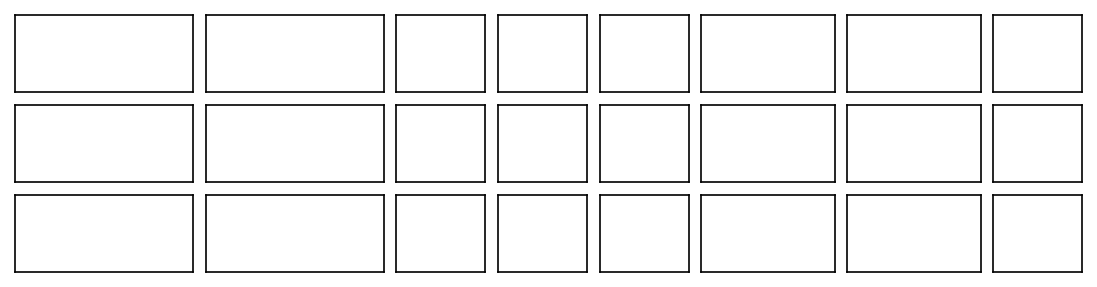

In [61]:
fig , axes = create_fig(ncols=8,nrows=3,size='double',h=0.25,w_ratios=[2,2,1,1,1,1.5,1.5,1])

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top','right']].set_visible(True)

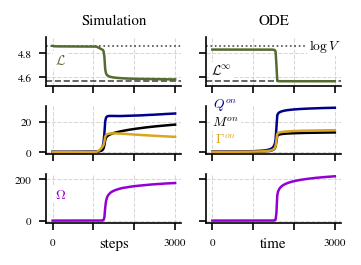

In [68]:
# Settings
colors = dict(loss='darkolivegreen',M='k',Q ='darkblue',G='goldenrod',omega='darkviolet')

# set_font_sizes('tight',factor=0.9)
set_font_sizes('custom',sizes=['s', 's', 's', 'xs', 'xs', 'xs', 's'],factor=0.9)



fig , axes = create_fig(ncols=2,nrows=3,h=0.23,size='double',w=3.5/11,sharey='row')#,layout='tight')


for i , (ax_col, data) in enumerate(zip(axes.T,[metrics,ode_metrics])):
    for j, (ax , names) in enumerate(zip(ax_col,[['loss'],['M','Q','G'],['omega']])):
        # ax.text(0.5,0.5,f'{i},{j}',transform=ax.transAxes, ha='center', va='center')
        for name in names:
            if name == 'loss':
                ax.axhline(y=limit_loss, color='k', linestyle='--', linewidth=0.8, label='limit loss',alpha=0.7)
                ax.axhline(y=np.log(V), color='k', linestyle=':', linewidth=0.8, label='log V',alpha=0.7)
                ax.set_ylim(bottom=4.53,top=4.93)
            ax.plot(data['step'], data[name], label=name, color=colors[name], linewidth=1.2)
        ax.grid(lw=0.5,ls='--',alpha=0.5)
        ax.set_xticks([0,1000,2000,3000],[0,None,None,3000])
        if j==0: ax.set_title(['Simulation','ODE'][i])
        if j==2: ax.set_xlabel(['steps','time'][i],labelpad=-5)
l_val = 0.15
locs = [(l_val,0.79),(0.63,0.54),(0.63,0.61),(0.63,0.47),(l_val,0.25),(0.92,0.85),(0.62,0.745)]
labels = [r'$\boldsymbol{\mathcal{L}}$',r'$M^{on}$',r'$Q^{on}$',r'$\Gamma^{on}$',r'$\Omega$',r'$\log V$',r'$\mathcal{L}^{\infty}$']
colors = ['darkolivegreen','k','darkblue','goldenrod','darkviolet','k','k']
for loc,lb,col in zip(locs,labels,colors):
    fig.text(loc[0],loc[1],lb,color=col,fontsize=6.5, bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 1},
             verticalalignment='center', horizontalalignment='center')

# Save figure as svg
path = Path('../../Manuscript/figures/svg/')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)
fig.savefig(path/'fig_ode_vs_simulation.svg', format='svg', bbox_inches='tight', dpi=300)

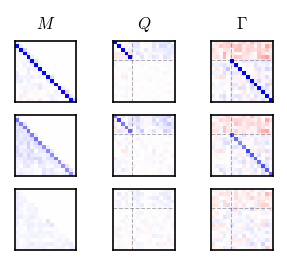

In [92]:
#
n_tot = 16
n_left = int(n_tot * rho) + 2
n_right = n_tot - n_left

titles = dict(M=r'$M$', Q=r'$Q$', G=r'$\Gamma$')

fig , axes = create_fig(ncols=3,nrows=3,h=0.23,size='double',w=3/11,sharey='row')

for i , (ax_col,key) in enumerate(zip(axes.T,['M','Q','G'])):
    for j, (ax , t_frac) in enumerate(zip(ax_col[::-1],t_fracs)):
        ax.spines[['top','right']].set_visible(True)
        ax.set_xticks([])
        ax.set_yticks([])
        mtx = artifacts[key][j][K-n_left:K+n_right,K-n_left:K+n_right]
        if key == 'M': #filter out the upper diagonal part of the matrix
            mtx = np.tril(mtx)
        lim = _range[key]*0.85
        ax.imshow(mtx, cmap='bwr_r', vmin=-lim, vmax=lim)
        if key in ['Q','G']:
            ax.axhline(n_left-0.5,color='black',ls='--',lw=0.5,alpha=0.3)
            ax.axvline(n_left-0.5,color='black',ls='--',lw=0.5,alpha=0.3)
        if j==2: ax.set_title(f'{titles[key]}',fontsize=8)

fig.savefig(path/'matrices.svg', format='svg', bbox_inches='tight', dpi=300)

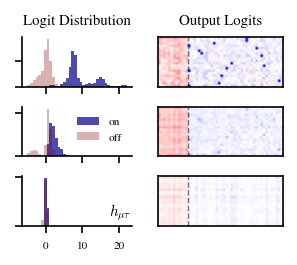

In [153]:
n_tot = 50
n_left = int(n_tot * rho) + 2
n_right = n_tot - n_left

colors = dict(on='darkblue',off='maroon')

fig , axes = create_fig(ncols=2,nrows=3,h=0.23,size='double',w=3/11,sharex='col',w_ratios=[1,1.4])

# First column distributions:
for i , ax in enumerate(axes.T[0][::-1]):
    # ax.text(0.5,0.5,f'{t_fracs[i]}',transform=ax.transAxes, ha='center', va='center')
    for j, key in enumerate(['on','off']):
        data = artifacts[key][i]
        ax.set_yticklabels([])
        ax.hist(data, bins=36, density=True, alpha=[0.7,0.3][j], label=key,range=(-5,22), color=colors[key])
axes[1,0].legend(frameon=False)
axes[0,0].set_title("Logit Distribution")
axes[2,0].set_xlabel(r'$h_{\mu\tau}$',loc='right',labelpad=-23)
# axes[0,0].set_title(r"")

# Second column matrixes:
for i , ax in enumerate(axes.T[1][::-1]):
    ax.spines[['top','right']].set_visible(True)
    ax.set_xticks([])
    ax.set_yticks([])
    mtx = artifacts['all'][i][:,K-n_left:K+n_right]
    lim = _range['all']*[0.2,0.5,0.5][i]
    ax.imshow(mtx, cmap='bwr_r', vmin=-lim, vmax=lim)
    ax.axvline(n_left-0.5,color='black',ls='--',lw=0.7,alpha=0.5)

axes[0,1].set_title("Output Logits")


fig.savefig(path/'logits.svg', format='svg', bbox_inches='tight', dpi=300)

In [ ]:
artifacts['on']

(785,)

In [ ]:
# Load configuration
# cfg = reader.load_config(run_id)
# L , V, d, rho, K , beta , bs , eta_0, lmbd, A, av_Pind, limit_loss = get_args(cfg)
# print(f'Loaded run {run_id} with parameters: L={L}, V={V}, d={d}, rho={rho}, K={K}, beta={beta}, bs={bs}, eta_0={eta_0:.4f}')
# print(f' lmbd={lmbd:.4f}, A={A:.4f}, av_Pind={av_Pind:.4f}, limit_loss={limit_loss:.4f}, log V = {np.log(V):.4f}')
